# Retention Analysis Notebook

This notebook profiles the master table created in SQL and compares retention segments in Python.

## Flow
1. Load master table
2. Create `segment`
3. Profile segments
4. Compare Early Returners vs Never Returners
5. Confirm findings : no variable explain the return gap


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Load data

Adjust the file name to match your export.

In [5]:
# Update the path if needed
df = pd.read_csv("/content/master_table.csv")
df.head()


,user_id,age,gender,country,first_order_date,first_order_value,first_product_category,returned,days_to_repeat,first_order_quartile
0,1,40,F,Brasil,2022-12-31 09:52:00.000,9.20,Blazers & Jackets,1,419.0,1
1,3,55,M,France,2024-06-07 03:06:00.000,214.92,Underwear,0,NaN,4
2,6,27,M,United Kingdom,2022-08-25 07:12:00.000,68.00,Pants,0,NaN,3
3,8,32,F,United Kingdom,2023-08-12 05:48:00.000,90.00,Fashion Hoodies & Sweatshirts,1,259.0,3
4,11,54,F,United States,2023-10-19 06:21:00.000,36.00,Sleep & Lounge,1,91.0,2


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55073 entries, 0 to 55072
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 55073 non-null  int64  
 1   age                     55073 non-null  int64  
 2   gender                  55073 non-null  object 
 3   country                 55073 non-null  object 
 4   first_order_date        55073 non-null  object 
 5   first_order_value       55073 non-null  float64
 6   first_product_category  55073 non-null  object 
 7   returned                55073 non-null  int64  
 8   days_to_repeat          16803 non-null  float64
 9   first_order_quartile    55073 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 4.2+ MB


## Create retention segment

This is the same logic used in SQL, but reproduced in Python for analysis.

In [7]:
df["segment"] = np.select(
    [
        df["days_to_repeat"].isna(),
        df["days_to_repeat"] <= 60,
        (df["days_to_repeat"] > 60) & (df["days_to_repeat"] <= 204),
        df["days_to_repeat"] > 204,
    ],
    [
        "Never Returner",
        "Early Returner",
        "Mid Returner",
        "Late Returner",
    ],
    default="Unknown"
)

df["segment"].value_counts(dropna=False)


,count
segment,
Never Returner,38270
Late Returner,8245
Mid Returner,4366
Early Returner,4192


## Segment profiling

Look for meaningful differences, not just numerical differences.

In [8]:
segment_order = ["Early Returner", "Mid Returner", "Late Returner", "Never Returner"]

def profile_numeric(df, group_col, value_col):
    return df.groupby(group_col)[value_col].agg(["count", "mean", "median"]).reindex(segment_order).round(2)

def profile_categorical(df, group_col, cat_col):
    return pd.crosstab(df[group_col], df[cat_col], normalize="index").reindex(segment_order).round(3) * 100


In [9]:
profile_numeric(df, "segment", "age")


,count,mean,median
segment,,,
Early Returner,4192,40.95,41.0
Mid Returner,4366,41.07,42.0
Late Returner,8245,41.21,42.0
Never Returner,38270,40.91,41.0


In [10]:
profile_numeric(df, "segment", "first_order_value")


,count,mean,median
segment,,,
Early Returner,4192,88.46,55.00
Mid Returner,4366,89.68,55.00
Late Returner,8245,87.06,55.66
Never Returner,38270,87.23,56.00


In [11]:
profile_numeric(df, "segment", "days_to_repeat")


,count,mean,median
segment,,,
Early Returner,4192,23.13,20.0
Mid Returner,4366,125.00,121.0
Late Returner,8245,555.75,461.0
Never Returner,0,NaN,NaN


In [12]:
profile_categorical(df, "segment", "gender")


gender,F,M
segment,,
Early Returner,51.7,48.3
Mid Returner,52.2,47.8
Late Returner,51.8,48.2
Never Returner,51.5,48.5


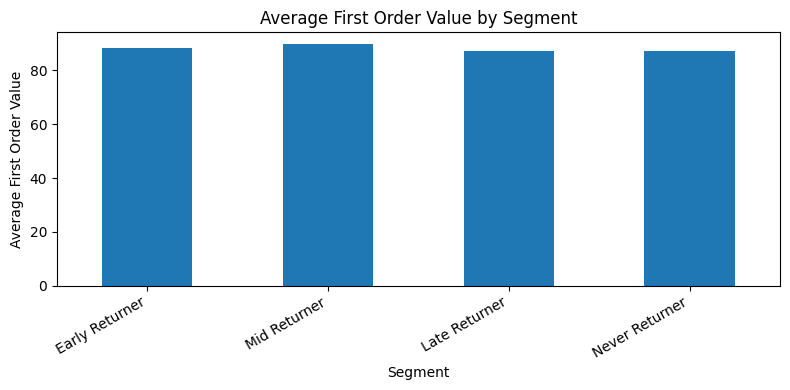

In [16]:
summary = df.groupby("segment")["first_order_value"].mean().reindex(segment_order)

fig, ax = plt.subplots(figsize=(8, 4))
summary.plot(kind="bar", ax=ax)
ax.set_title("Average First Order Value by Segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Average First Order Value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [19]:
profile_categorical(df, "segment", "country")

country,Australia,Belgium,Brasil,China,Colombia,España,France,Germany,Japan,Poland,South Korea,Spain,United Kingdom,United States
segment,,,,,,,,,,,,,,
Early Returner,2.2,1.4,14.4,34.3,0.0,0.0,4.7,4.5,2.6,0.1,5.2,4.4,4.6,21.6
Mid Returner,1.9,1.0,14.2,34.0,0.0,0.0,4.0,4.2,2.7,0.2,5.3,4.3,5.0,23.1
Late Returner,2.2,1.3,14.7,34.3,0.0,0.0,4.6,3.9,2.1,0.2,5.1,4.6,4.8,22.1
Never Returner,2.2,1.2,14.4,33.3,0.0,0.0,4.6,4.3,2.2,0.3,5.4,4.3,4.9,22.8


In [20]:
profile_categorical(df, "segment", "first_product_category")

first_product_category,Accessories,Active,Blazers & Jackets,Clothing Sets,Dresses,Fashion Hoodies & Sweatshirts,Intimates,Jeans,Jumpsuits & Rompers,Leggings,Maternity,Outerwear & Coats,Pants,Pants & Capris,Plus,Shorts,Skirts,Sleep & Lounge,Socks,Socks & Hosiery,Suits,Suits & Sport Coats,Sweaters,Swim,Tops & Tees,Underwear
segment,,,,,,,,,,,,,,,,,,,,,,,,,,
Early Returner,6.2,4.9,1.7,0.1,3.1,6.2,7.6,6.5,0.8,2.2,2.8,4.0,3.5,2.1,2.7,6.0,1.3,6.1,4.1,2.6,0.4,2.5,5.4,5.4,7.2,4.6
Mid Returner,6.1,5.0,1.4,0.2,2.9,6.1,8.3,6.0,0.4,2.3,2.8,3.9,3.8,2.0,2.5,6.4,1.2,6.0,4.1,2.2,0.5,2.5,6.3,5.7,7.1,4.1
Late Returner,6.1,5.6,1.7,0.1,3.2,5.9,8.2,6.0,0.6,2.0,2.6,3.9,3.5,2.1,2.5,6.3,1.1,6.2,4.2,2.5,0.4,2.0,5.1,6.2,7.0,4.9
Never Returner,6.1,5.1,1.6,0.1,2.9,5.8,8.0,5.7,0.6,2.1,2.7,4.0,3.6,1.9,2.8,6.1,1.3,6.2,4.4,2.8,0.5,2.3,5.6,5.9,7.1,4.7
